In [1]:
# =============================================================
# UAE FinPay Neobank — AI-Powered Customer Analytics
# =============================================================
# Author: Kunal Sharma
# Date: August 2026
#
# AI Models Implemented:
# 1. Predictive Churn Model (Logistic Regression + RF)
#    Predicts 30-day churn probability per customer
#
# 2. ML Customer Segmentation (KMeans)
#    Behavioural segments: Champions, At-Risk,
#    New Customers, Hibernating
#
# 3. Transaction Anomaly Detection (Isolation Forest)
#    Flags unusual spending patterns without fraud labels
#
# Business Value:
# - Identifies AED revenue at risk from predicted churners
# - Enables personalised retention by segment
# - Flags anomalous transactions for risk review
#
# PDPL Note: ML models use anonymised customer_id only.
# No personally identifiable information processed.
# =============================================================
print("UAE FinPay Neobank AI Analytics - Starting")
print("=" * 55)


UAE FinPay Neobank AI Analytics - Starting


Connected to database
Churn: 7,043 | Customers: 50,000 | Transactions: 99,990

LR AUC: 0.8232 | RF AUC: 0.7712 | Best: Logistic Regression
Predicted churners: 1,343
Revenue at risk: AED 392,568


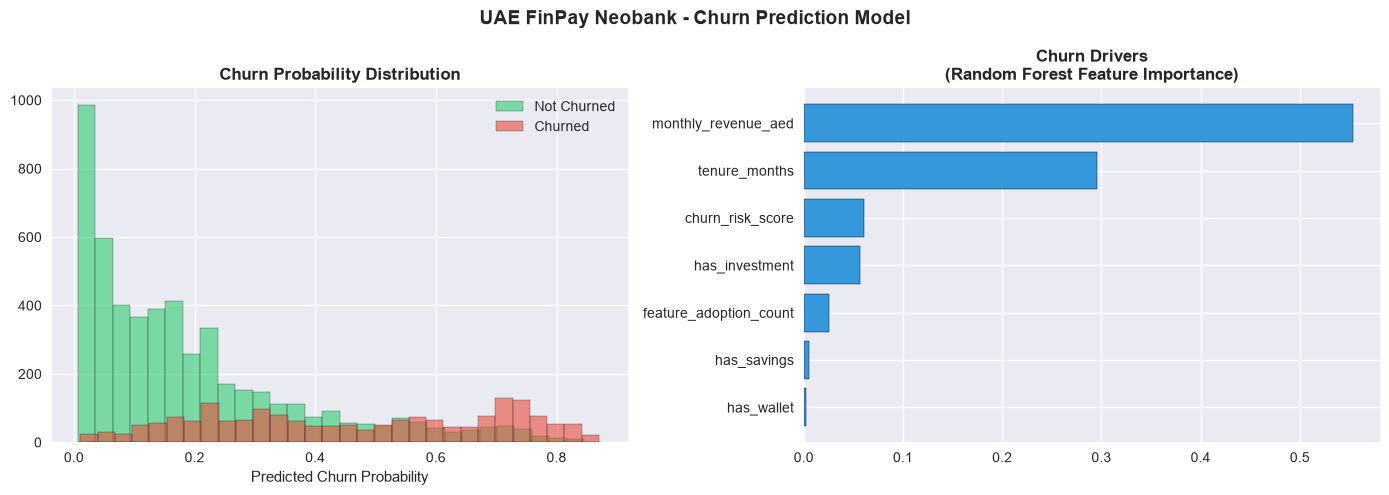

Chart 5 saved

Optimal clusters: 3
Segments: {'Hibernating': 5366, 'New_Customers': 1677}


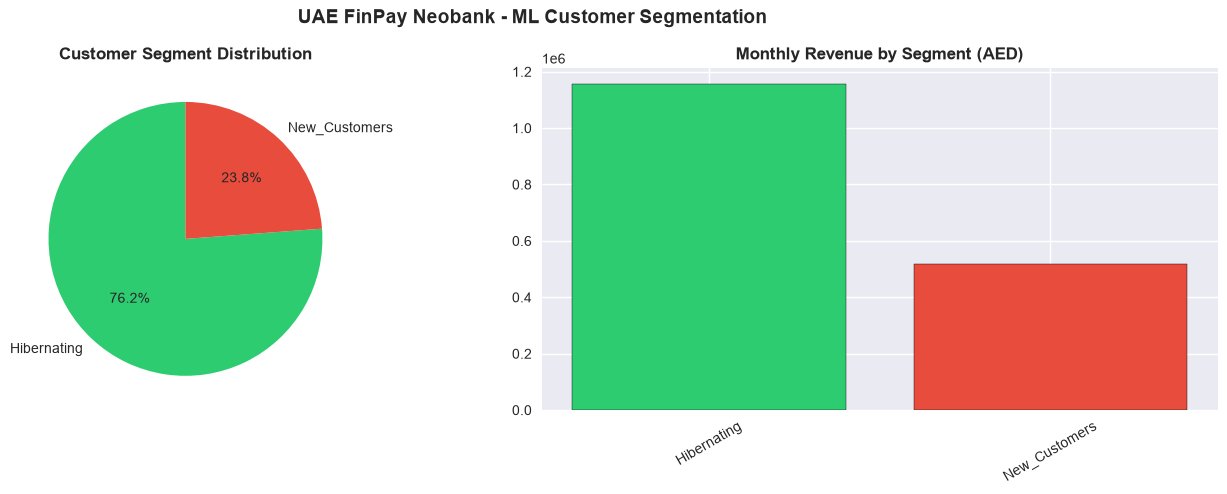

Chart 6 saved

Anomalies: 4,987 (5.0%)
High-value anomalies: 4,957

ml_churn_predictions: 7,043 rows saved
ml_anomaly_scores: 99,990 rows saved

UAE FinPay Neobank AI Analytics - Executive Summary
Model 1 - Churn Prediction
  Best model: Logistic Regression (AUC: 0.8232)
  Predicted churners: 1,343
  Revenue at risk: AED 392,568

Model 2 - Segmentation (k=3)
  Hibernating: 5,366 (76.2%)
  New_Customers: 1,677 (23.8%)

Model 3 - Anomaly Detection
  Anomaly rate: 5.0%
  High-value anomalies: 4,957

ML tables written to PostgreSQL
  raw.ml_churn_predictions: 7,043 rows
  raw.ml_anomaly_scores: 99,990 rows


In [2]:
# UAE FinPay Neobank AI Analytics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, silhouette_score
import os
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
os.makedirs("charts", exist_ok=True)

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Hellboy@0404",
    host="localhost",
    port=5432,
    database="neobank_db"
)
engine = create_engine(connection_url)
print("Connected to database")

df_churn = pd.read_sql("SELECT * FROM dbt_dev.fct_churn_signals", engine)
df_customers = pd.read_sql("SELECT * FROM dbt_dev.stg_customers", engine)
df_txn = pd.read_sql("SELECT * FROM dbt_dev.stg_transactions", engine)
print(f"Churn: {len(df_churn):,} | Customers: {len(df_customers):,} | Transactions: {len(df_txn):,}")

features = ["tenure_months","monthly_revenue_aed","has_wallet",
            "has_savings","has_investment","feature_adoption_count",
            "churn_risk_score"]
df_model = df_churn[features + ["is_churned","customer_id"]].copy().fillna(0)
X = df_model[features]
y = df_model["is_churned"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_s, y_train)
lr_proba = lr.predict_proba(X_test_s)[:,1]
lr_auc = roc_auc_score(y_test, lr_proba)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_proba)

best_model_name = "Logistic Regression" if lr_auc > rf_auc else "Random Forest"
best_auc = max(lr_auc, rf_auc)
print(f"\nLR AUC: {lr_auc:.4f} | RF AUC: {rf_auc:.4f} | Best: {best_model_name}")

df_churn_full = df_churn.copy().fillna(0)
if lr_auc > rf_auc:
    df_churn_full["churn_probability"] = lr.predict_proba(
        scaler.transform(df_churn_full[features]))[:,1]
else:
    df_churn_full["churn_probability"] = rf.predict_proba(
        df_churn_full[features])[:,1]

df_churn_full["churn_probability_pct"] = (df_churn_full["churn_probability"]*100).round(2)
df_churn_full["predicted_churn_flag"] = (df_churn_full["churn_probability"]>0.5).astype(int)
revenue_at_risk = df_churn_full[df_churn_full["predicted_churn_flag"]==1]["monthly_revenue_aed"].sum()
print(f"Predicted churners: {df_churn_full['predicted_churn_flag'].sum():,}")
print(f"Revenue at risk: AED {revenue_at_risk:,.0f}")

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("UAE FinPay Neobank - Churn Prediction Model", fontsize=14, fontweight="bold")
axes[0].hist(df_churn_full[df_churn_full["is_churned"]==0]["churn_probability"],
             bins=30, alpha=0.6, color="#2ecc71", label="Not Churned", edgecolor="black")
axes[0].hist(df_churn_full[df_churn_full["is_churned"]==1]["churn_probability"],
             bins=30, alpha=0.6, color="#e74c3c", label="Churned", edgecolor="black")
axes[0].set_title("Churn Probability Distribution", fontweight="bold")
axes[0].set_xlabel("Predicted Churn Probability")
axes[0].legend()

importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
axes[1].barh(importance_df["feature"], importance_df["importance"],
             color="#3498db", edgecolor="black")
axes[1].set_title("Churn Drivers\n(Random Forest Feature Importance)", fontweight="bold")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("charts/05_churn_prediction_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved")

seg_features = ["tenure_months","monthly_revenue_aed","feature_adoption_count","churn_probability"]
df_seg = df_churn_full[seg_features+["customer_id","emirate"]].copy().fillna(0)
scaler_seg = StandardScaler()
X_seg = scaler_seg.fit_transform(df_seg[seg_features])

silhouette_scores = []
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_seg)
    silhouette_scores.append(silhouette_score(X_seg, labels))
optimal_k = range(2,8)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal clusters: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_seg["cluster"] = kmeans.fit_predict(X_seg)
cluster_profile = df_seg.groupby("cluster").agg(
    customer_count=("customer_id","count"),
    avg_tenure=("tenure_months","mean"),
    avg_revenue_aed=("monthly_revenue_aed","mean"),
    avg_feature_adoption=("feature_adoption_count","mean"),
    avg_churn_probability=("churn_probability","mean")
).round(2)

def label_cluster(row):
    if (row["avg_revenue_aed"] > cluster_profile["avg_revenue_aed"].median()
        and row["avg_churn_probability"] < cluster_profile["avg_churn_probability"].median()):
        return "Champions"
    elif (row["avg_churn_probability"] > cluster_profile["avg_churn_probability"].median()
          and row["avg_revenue_aed"] > cluster_profile["avg_revenue_aed"].median()):
        return "At_Risk_High_Value"
    elif row["avg_tenure"] < cluster_profile["avg_tenure"].median():
        return "New_Customers"
    else:
        return "Hibernating"

cluster_profile["segment_label"] = cluster_profile.apply(label_cluster, axis=1)
label_map = cluster_profile["segment_label"].to_dict()
df_seg["segment_label"] = df_seg["cluster"].map(label_map)
df_churn_full["segment_label"] = df_seg["segment_label"].values
print(f"Segments: {df_churn_full['segment_label'].value_counts().to_dict()}")

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("UAE FinPay Neobank - ML Customer Segmentation", fontsize=14, fontweight="bold")
seg_counts = df_churn_full["segment_label"].value_counts()
colors = ["#2ecc71","#e74c3c","#3498db","#f39c12"]
axes[0].pie(seg_counts.values, labels=seg_counts.index, colors=colors,
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Customer Segment Distribution", fontweight="bold")
seg_revenue = df_churn_full.groupby("segment_label")["monthly_revenue_aed"].sum().sort_values(ascending=False)
axes[1].bar(seg_revenue.index, seg_revenue.values, color=colors[:len(seg_revenue)],
            edgecolor="black")
axes[1].set_title("Monthly Revenue by Segment (AED)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("charts/06_customer_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 6 saved")

txn_features = ["amount_aed","is_fraud"]
df_txn_model = df_txn[txn_features+["transaction_id","customer_id","emirate"]].copy().fillna(0)
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
df_txn_model["anomaly_score"] = iso_forest.fit_predict(df_txn_model[txn_features])
df_txn_model["is_anomaly"] = (df_txn_model["anomaly_score"]==-1).astype(int)
df_txn_model["anomaly_confidence"] = (-iso_forest.score_samples(df_txn_model[txn_features]))
total_anomalies = df_txn_model["is_anomaly"].sum()
anomaly_rate = df_txn_model["is_anomaly"].mean()*100
high_value_anomalies = df_txn_model[(df_txn_model["is_anomaly"]==1)&(df_txn_model["amount_aed"]>5000)]
print(f"\nAnomalies: {total_anomalies:,} ({anomaly_rate:.1f}%)")
print(f"High-value anomalies: {len(high_value_anomalies):,}")

churn_output = df_churn_full[["customer_id","churn_probability_pct",
                               "predicted_churn_flag","segment_label",
                               "monthly_revenue_aed","emirate"]].copy()
churn_output.to_sql("ml_churn_predictions", schema="raw", con=engine,
                     if_exists="replace", index=False)
print(f"\nml_churn_predictions: {len(churn_output):,} rows saved")

anomaly_output = df_txn_model[["transaction_id","customer_id","amount_aed",
                                "is_anomaly","anomaly_confidence","emirate"]].copy()
anomaly_output.to_sql("ml_anomaly_scores", schema="raw", con=engine,
                       if_exists="replace", index=False)
print(f"ml_anomaly_scores: {len(anomaly_output):,} rows saved")

print("\n" + "="*55)
print("UAE FinPay Neobank AI Analytics - Executive Summary")
print("="*55)
print(f"Model 1 - Churn Prediction")
print(f"  Best model: {best_model_name} (AUC: {best_auc:.4f})")
print(f"  Predicted churners: {df_churn_full['predicted_churn_flag'].sum():,}")
print(f"  Revenue at risk: AED {revenue_at_risk:,.0f}")
print(f"\nModel 2 - Segmentation (k={optimal_k})")
for label, count in seg_counts.items():
    print(f"  {label}: {count:,} ({count/len(df_churn_full)*100:.1f}%)")
print(f"\nModel 3 - Anomaly Detection")
print(f"  Anomaly rate: {anomaly_rate:.1f}%")
print(f"  High-value anomalies: {len(high_value_anomalies):,}")
print(f"\nML tables written to PostgreSQL")
print(f"  raw.ml_churn_predictions: {len(churn_output):,} rows")
print(f"  raw.ml_anomaly_scores: {len(anomaly_output):,} rows")
print("="*55)
